# VAE Pretraining
Here we will pretrain a VAE using an architecture very similar to the Gómez-Bombarelli / `molecular-vae` style (conv encoder + GRU decoder). The key change is that we will now use SELFIES instead of SMILES.

We will train 3 models from different data sources: ChemBL, Zinc, and ChemBL + Zinc.


### Imports and config

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf
from tqdm.auto import tqdm

SEED = 42
MAX_LEN = 120  # max SELFIES token length before EOS
VAL_FRAC = 0.10
TEST_FRAC = 0.10

LATENT_DIM = 292
EPOCHS = 20
BATCH_SIZE = 128
LR = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)

device: mps
torch: 2.10.0
selfies: 2.1.1


/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load cleaned datasets

In [2]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH, TOX21_TRAIN_PATH, TOX21_VAL_PATH, TOX21_TEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)

# tox21 is loaded for later post-training only (not used for pretraining here)
tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

print(f"ChemBL unique SMILES: {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:   {len(zinc_smiles):,}")
print(f"tox21 train/val/test: {len(tox21_train_smiles):,} / {len(tox21_val_smiles):,} / {len(tox21_test_smiles):,}")

ChemBL unique SMILES: 23,871
Zinc unique SMILES:   249,455
tox21 train/val/test: 6,258 / 782 / 783


### Convert to SELFIES and split datasets
This cell builds the three pretraining datasets and creates train/val/test splits.

In [3]:
def smiles_to_selfies(smiles_list: list[str]) -> tuple[list[str], int]:
    out = []
    failed = 0
    for smi in smiles_list:
        try:
            out.append(sf.encoder(smi))
        except Exception:
            failed += 1
    return out, failed


def filter_selfies_len(selfies_list: list[str], max_len: int = MAX_LEN) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


def split_list(items: list[str], val_frac: float, test_frac: float, seed: int) -> tuple[list[str], list[str], list[str]]:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(items))
    rng.shuffle(idx)

    n = len(items)
    n_test = max(1, int(round(n * test_frac)))
    n_val = max(1, int(round(n * val_frac)))

    if n_test + n_val >= n:
        n_test = max(1, n // 10)
        n_val = max(1, n // 10)

    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    train = [items[i] for i in train_idx]
    val = [items[i] for i in val_idx]
    test = [items[i] for i in test_idx]
    return train, val, test


# Requested pretraining set
pre_train_chembl_zinc = list(dict.fromkeys(chembl_smiles + zinc_smiles))

chembl_selfies, chembl_failed = smiles_to_selfies(chembl_smiles)
zinc_selfies, zinc_failed = smiles_to_selfies(zinc_smiles)
combo_selfies, combo_failed = smiles_to_selfies(pre_train_chembl_zinc)

chembl_selfies = filter_selfies_len(chembl_selfies, max_len=MAX_LEN)
zinc_selfies = filter_selfies_len(zinc_selfies, max_len=MAX_LEN)
combo_selfies = filter_selfies_len(combo_selfies, max_len=MAX_LEN)

split_sets = {
    "chembl_zinc": split_list(combo_selfies, VAL_FRAC, TEST_FRAC, seed=SEED),
    "chembl": split_list(chembl_selfies, VAL_FRAC, TEST_FRAC, seed=SEED + 1),
    "zinc": split_list(zinc_selfies, VAL_FRAC, TEST_FRAC, seed=SEED + 2),
}

print(f"SELFIES conversion failures -> combo={combo_failed}, chembl={chembl_failed}, zinc={zinc_failed}")
for name, (tr, va, te) in split_sets.items():
    print(f"{name:12s}: train={len(tr):,}, val={len(va):,}, test={len(te):,}")

SELFIES conversion failures -> combo=0, chembl=0, zinc=0
chembl_zinc : train=218,336, val=27,292, test=27,292
chembl      : train=18,776, val=2,347, test=2,347
zinc        : train=199,563, val=24,946, test=24,946


### Tokenization and encoding
This cell creates a shared SELFIES tokenizer and encodes each split into padded token IDs.

In [4]:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"


def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))


# Shared vocab from chembl_zinc training split
base_train = split_sets["chembl_zinc"][0]
base_tokens = [tokenize_selfies(s) for s in base_train]

vocab_tokens = sorted({tok for seq in base_tokens for tok in seq})
ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

# Max length 120 (+EOS token)
SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

if VOCAB_SIZE < 29:
    raise ValueError("Vocab is too small for Paper-like conv kernels (9, 9, 11).")


def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def encode_list(selfies_list: list[str]) -> np.ndarray:
    out = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out[i, :len(ids)] = ids
    return out


encoded_data = {}
for run_name, (train_s, val_s, test_s) in split_sets.items():
    encoded_data[run_name] = {
        "train": encode_list(train_s),
        "val": encode_list(val_s),
        "test": encode_list(test_s),
    }
    print(
        f"{run_name:12s}: "
        f"train={encoded_data[run_name]['train'].shape}, "
        f"val={encoded_data[run_name]['val'].shape}, "
        f"test={encoded_data[run_name]['test'].shape}"
    )

print(f"VOCAB_SIZE={VOCAB_SIZE}, SEQ_LEN={SEQ_LEN}")

chembl_zinc : train=(218336, 121), val=(27292, 121), test=(27292, 121)
chembl      : train=(18776, 121), val=(2347, 121), test=(2347, 121)
zinc        : train=(199563, 121), val=(24946, 121), test=(24946, 121)
VOCAB_SIZE=115, SEQ_LEN=121


### Paper-like SELFIES VAE
This cell defines the Paper-like VAE architecture adapted to SELFIES token inputs.

In [5]:
class TokenDataset(Dataset):
    def __init__(self, x: np.ndarray):
        self.x = torch.from_numpy(x).long()

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx]


class PaperLikeSelfiesVAE(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, latent_dim: int = 292):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        self.conv_1 = nn.Conv1d(in_channels=seq_len, out_channels=9, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, seq_len, vocab_size)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            flat = d.view(1, -1).size(1)

        self.linear_0 = nn.Linear(flat, 435)
        self.linear_1 = nn.Linear(435, latent_dim)
        self.linear_2 = nn.Linear(435, latent_dim)

        self.linear_3 = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(input_size=292, hidden_size=501, num_layers=3, batch_first=True)
        self.linear_4 = nn.Linear(501, vocab_size)

    def encoder(self, x_onehot: torch.Tensor):
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.view(x.size(0), -1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, mean: torch.Tensor, logvar: torch.Tensor):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mean

    def decode(self, z: torch.Tensor):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        out2 = out.contiguous().view(-1, out.size(-1))
        probs = F.softmax(self.linear_4(out2), dim=1)
        return probs.contiguous().view(out.size(0), self.seq_len, self.vocab_size)

    def forward(self, x_onehot: torch.Tensor):
        mean, logvar = self.encoder(x_onehot)
        z = self.sampling(mean, logvar)
        probs = self.decode(z)
        return probs, mean, logvar


def ids_to_onehot(x_ids: torch.Tensor, vocab_size: int):
    return F.one_hot(x_ids, num_classes=vocab_size).float()


def vae_loss(pred_probs: torch.Tensor, x_onehot: torch.Tensor, mean: torch.Tensor, logvar: torch.Tensor):
    recon = F.binary_cross_entropy(pred_probs, x_onehot, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return recon + kl, recon, kl

### Training and evaluation helpers
This cell defines simple train and evaluation loops used for all three runs.

In [6]:
def make_loader(x: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(TokenDataset(x), batch_size=batch_size, shuffle=shuffle)


def evaluate(model: nn.Module, x: np.ndarray, run_name: str | None = None, ep: int | None = None):
    loader = make_loader(x, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()

    total_sum, recon_sum, kl_sum, n = 0.0, 0.0, 0.0, 0
    desc = f"{run_name} ep {ep:03d} eval" if run_name is not None and ep is not None else "eval"
    with torch.no_grad():
        for x_ids in tqdm(loader, desc=desc, leave=False):
            x_ids = x_ids.to(device)
            x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

            pred_probs, mean, logvar = model(x_onehot)
            total, recon, kl = vae_loss(pred_probs, x_onehot, mean, logvar)

            b = x_ids.size(0)
            total_sum += total.item()
            recon_sum += recon.item()
            kl_sum += kl.item()
            n += b

    return {
        "total": total_sum / n,
        "recon": recon_sum / n,
        "kl": kl_sum / n,
    }


def train_one_run(run_name: str, train_x: np.ndarray, val_x: np.ndarray):
    model = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=LR)
    train_loader = make_loader(train_x, batch_size=BATCH_SIZE, shuffle=True)

    history = {"train_total": [], "val_total": []}

    for ep in tqdm(range(1, EPOCHS + 1), desc=f"{run_name} epochs"):
        model.train()
        total_sum, n = 0.0, 0

        for x_ids in tqdm(train_loader, desc=f"{run_name} ep {ep:03d} train", leave=False):
            x_ids = x_ids.to(device)
            x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

            optim.zero_grad()
            pred_probs, mean, logvar = model(x_onehot)
            total, _, _ = vae_loss(pred_probs, x_onehot, mean, logvar)
            total.backward()
            optim.step()

            b = x_ids.size(0)
            total_sum += total.item()
            n += b

        train_loss = total_sum / n
        val_loss = evaluate(model, val_x, run_name=run_name, ep=ep)["total"]
        history["train_total"].append(train_loss)
        history["val_total"].append(val_loss)

        print(f"{run_name:12s} ep {ep:03d} | train={train_loss:.4f} val={val_loss:.4f}")

    return model, history

### Train the 3 pretraining models
This cell trains and compares `chembl_zinc`, `chembl`, and `zinc` runs.

In [7]:
run_order = ["chembl_zinc", "chembl", "zinc"]
models = {}
histories = {}
results = {}

save_dir = Path("artifacts") / "pretraining_checkpoints"
save_dir.mkdir(parents=True, exist_ok=True)

for run_name in tqdm(run_order, desc="training runs"):
    train_x = encoded_data[run_name]["train"]
    val_x = encoded_data[run_name]["val"]
    test_x = encoded_data[run_name]["test"]

    print(f"\n===== {run_name} =====")
    model, history = train_one_run(run_name, train_x, val_x)
    test_metrics = evaluate(model, test_x, run_name=run_name, ep=EPOCHS)

    models[run_name] = model
    histories[run_name] = history

    ckpt_path = save_dir / f"paper_like_selfies_{run_name}.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "token_to_idx": TOKEN_TO_IDX,
            "seq_len": SEQ_LEN,
            "vocab_size": VOCAB_SIZE,
            "max_len": MAX_LEN,
            "history": history,
            "test_metrics": test_metrics,
        },
        ckpt_path,
    )

    results[run_name] = {
        "n_train": len(train_x),
        "n_val": len(val_x),
        "n_test": len(test_x),
        "final_train_loss": history["train_total"][-1],
        "final_val_loss": history["val_total"][-1],
        "test_total": test_metrics["total"],
        "test_recon": test_metrics["recon"],
        "test_kl": test_metrics["kl"],
        "checkpoint": str(ckpt_path),
    }

results_df = pd.DataFrame(results).T.sort_values("test_total")
results_df

training runs:   0%|          | 0/3 [00:00<?, ?it/s]


===== chembl_zinc =====


chembl_zinc  ep 001 | train=130.1505 val=122.2941


chembl_zinc  ep 002 | train=123.4965 val=125.5040


chembl_zinc  ep 003 | train=117.2014 val=112.8894


...

zinc         ep 018 | train=103.7018 val=71.3255


zinc         ep 019 | train=54.5221 val=42.2803


zinc         ep 020 | train=38.3235 val=38.6275


training runs: 100%|██████████| 3/3 [4:29:03<00:00, 5381.10s/it]  


,n_train,n_val,n_test,final_train_loss,final_val_loss,test_total,test_recon,test_kl,checkpoint
chembl_zinc,218336,27292,27292,33.939693,32.083597,32.306929,31.415241,0.891688,artifacts/pretraining_checkpoints/paper_like_s...
zinc,199563,24946,24946,38.323521,38.62752,38.386445,37.593068,0.793377,artifacts/pretraining_checkpoints/paper_like_s...
chembl,18776,2347,2347,155.872361,154.146057,154.61557,154.337671,0.277898,artifacts/pretraining_checkpoints/paper_like_s...


### Plot training curves
This cell plots train and validation loss curves for the three runs.

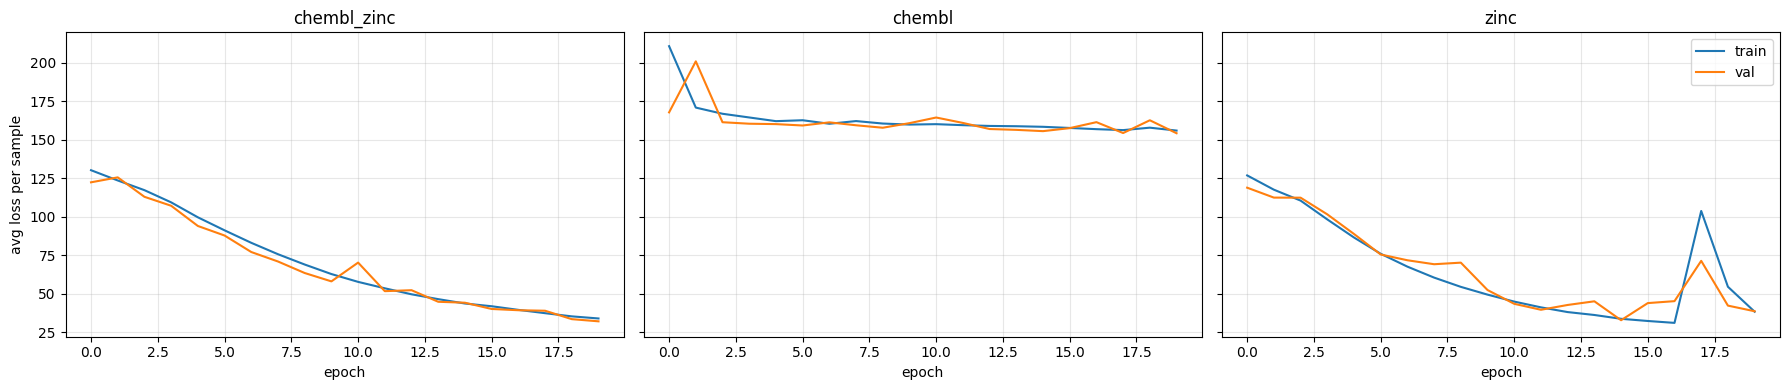

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, run_name in zip(axes, run_order):
    h = histories[run_name]
    ax.plot(h["train_total"], label="train")
    ax.plot(h["val_total"], label="val")
    ax.set_title(run_name)
    ax.set_xlabel("epoch")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("avg loss per sample")
axes[-1].legend()
plt.tight_layout()
plt.show()

### Quick reconstruction check
This cell prints a few original vs reconstructed SELFIES examples from each test split.

In [9]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        if tok == PAD:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(run_name: str, n: int = 5, seed: int = 42):
    model = models[run_name]
    model.eval()

    test_selfies = split_sets[run_name][2]
    test_ids = encoded_data[run_name]["test"]

    rng = np.random.default_rng(seed)
    k = min(n, len(test_ids))
    idxs = rng.choice(len(test_ids), size=k, replace=False)

    x_ids = torch.from_numpy(test_ids[idxs]).long().to(device)
    x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

    with torch.no_grad():
        pred_probs, _, _ = model(x_onehot)
        pred_ids = pred_probs.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print()


for rn in run_order:
    print(f"\n=== {rn} ===")
    show_reconstructions(rn, n=5, seed=SEED)


=== chembl_zinc ===
[0] exact=False
orig: [C][C][Branch1][C][C][C@H1][Branch1][C][C][C][N][C][=Branch1][C][=O][C][C][C][C@H1][C][C][C@@H1][Branch1][Ring2][C][Ring1][#Branch1][NH2+1][Ring1][=Branch1]
pred: [C][C][Branch1][C][C][C@H1][Branch1][C][C][C][N][C][=Branch1][C][=O][C][C][C][C][NH2+1][C][C@@H1][Branch1][=Branch1][C][Ring1][Ring1][C][Ring1][#Branch1]

[1] exact=False
orig: [C][C][C@@H1][Branch2][Ring1][=Branch1][O][C][=Branch1][C][=O][C][=C][C][=C][C][Branch1][#Branch1][N][C][Branch1][C][C][=O][=C][Ring1][#Branch2][C][=Branch1][C][=O][N][C][C][=C][Branch1][C][C][O][N][=Ring1][=Branch1]
pred: [C][C][C@@H1][Branch2][Ring1][O][O][C][=Branch1][C][=O][C][=C][C][=C][C][Branch1][#Branch2][N][Branch1][Branch1][C][C][=O][=C][Ring1][#Branch2][C][=Branch1][C][=O][N][C][C][C][C][C][C][C][N][=Ring1][C]

[2] exact=False
orig: [Cl][C][C@H1][C][C][C][O][C@H1][Ring1][=Branch1][C][=C][C][=C][Branch1][C][Cl][S][Ring1][=Branch1]
pred: [Cl][C][C@H1][C][C][C][C][Ring1][Ring1][=Branch1][C][=C][C][=C][

In [15]:
# Tox21 test token accuracy (PreTrained-style non-pad token accuracy)
from torch.utils.data import DataLoader, TensorDataset

# 1) Build tox21 test tensor using same tokenizer as this notebook
tox21_test_selfies, tox21_failed = smiles_to_selfies(tox21_test_smiles)
tox21_test_selfies = filter_selfies_len(tox21_test_selfies, max_len=MAX_LEN)
tox21_test_x = encode_list(tox21_test_selfies)

# 2) Evaluate token accuracy with chembl_zinc model
model = models["chembl_zinc"].to(device).eval()
loader = DataLoader(TensorDataset(torch.from_numpy(tox21_test_x).long()), batch_size=BATCH_SIZE, shuffle=False)

n_correct = 0
n_nonpad = 0

with torch.no_grad():
    for (x_ids,) in loader:
        x_ids = x_ids.to(device)
        x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)
        pred_probs, _, _ = model(x_onehot)  # Thomas_VAE model returns probabilities
        preds = pred_probs.argmax(dim=-1)

        mask = x_ids != PAD_IDX
        n_correct += ((preds == x_ids) & mask).sum().item()
        n_nonpad += mask.sum().item()

tox21_token_acc = n_correct / max(n_nonpad, 1)

print(f"tox21_test samples (raw): {len(tox21_test_smiles)}")
print(f"tox21_test selfies usable: {len(tox21_test_selfies)} | selfies failed: {tox21_failed}")
print(f"tox21_test non-pad token accuracy (chembl_zinc): {tox21_token_acc:.4f}")

tox21_test samples (raw): 783
tox21_test selfies usable: 765 | selfies failed: 0
tox21_test non-pad token accuracy (chembl_zinc): 0.7196


### Notes for later tox21 post-training
tox21 data is loaded and reserved, and you can reuse the saved checkpoints/tokenizer state for post-training.